<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/TNS1_Ex8_InformationTheory/TNS_I_Exercise_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Information theory

## Introduction
You are provided with four (synthetic) neural signals, sampled over time.  You will assess the statistical association or dependency of pairs of signals.  To this end, you will use both traditional statistics (Pearson's correlation coefficient) and entropy-based statistics (mutual information).

The goals of this exercise are (i) to learn how to compute the mutual information of signals, (ii) to understand how mutual information differs from traditional correlation/covariance statistics.


## 4 neurons
You are recording the activity of four neurons at periodic intervals (for example, of $50~\mathit{ms}$ duration).  For computational convenience, you discretise the activity of each neuron in terms of discrete *levels*, numbering from $1$  (weakest activity) to 11 (strongest activity).

You would like to know whether and how the respective activities two neurons are associated with each other or depend on each other.  Is one activity correlated with another?  Is one activity informative about another? Or are the two activities entirely independent?  To get answers, you compute both the coefficient of covariance and the mutual information for pairs of neurons.

## Obtaining discretised activities

The supplied function ```fourneurons()``` generates four vectors, $r_1$, $r_2$, $r_3$ und $r_4$, with $N$ values each.  The values are integer numbers from 1 to 11 and correspond to the activity levels observed in successive intervals.  Start by generating at least $2000$ activity values ($N\geq 2000$).

## Marginal and joint probabilities

For each of the four neurons, obtain the marginal probabilities $P(r_1)$, $P(r_2)$, $P(r_3)$ and $P(r_3)$ of different activity levels, using Matlab function ```numpy.histogram()```.  The results are four vectors of size $[1\times 11]$.

For each of three pairs of neuronal activity levels -- $(r_1,r_2)$, $(r_1,r_3)$, $(r_1,r_4)$ -- obtain the joint probabilities $P(r_1,r_2)$, $P(r_1,r_3)$, and $P(r_1,r_4)$ of different combinations of activity levels, using ```numpy.histogram2d()```.  The results are three matrices of size $[11\times 11]$.

Illustrate the marginal and joint probabilities graphically.

## Coefficient of correlation

Compute the coefficients of correlation, $\rho_{12}$, $\rho_{13}$, and $\rho_{14}$, for each neuron pair with the built-in function ```np.corrcoef()```:

$$
\rho_{ij} = \frac
  {
  \langle (r_i - \langle {r_i} \rangle )
  \cdot
  (r_j - \langle {r_j} \rangle ) \rangle
  }{
  \sqrt{\langle \left( r_i - \langle {r_i} \rangle \right)^2 \rangle}
  \cdot
  \sqrt{\langle \left( r_j - \langle {r_j} \rangle \right)^2 \rangle}
  }
$$

Here, $\langle{r_i}\rangle$ is the average (the expected value) and $\left\langle\left(r_i - \langle{r_i}\rangle\right)^2 \right\rangle$ is the average square deviation (an estimate for the variance) from the mean of the variable.

Note the Pearson correlation can be expressed as the division of covariance of the two variables. This value is unbounded. Dividing by the product of the individual standard deviations normalises the value between -1 and 1.

Furthermore, note the square of the Pearson correlation coefficient is a measure of "how much more variance is explained against a mean-only model".


## Mutual information

Compute marginal entropies $H(r_1)$, $H(r_2)$, $H(r_3)$, and $H(r_4)$, joint entropies $H(r_1, r_2)$,  $H(r_1, r_3)$, and $H(r_1, r_4)$ for each neuron pair.  It is convenient to program a function for this purpose.
$$
H(r_i)=-\sum_{r_i=1}^{11} P(r_i) \, \log_2 P(r_i), \qquad\qquad H(r_i,r_j)=-\sum_{r_i=1}^{11} \sum_{r_j=1}^{11} P(r_i,r_j) \, \log_2 P(r_i,r_j)
$$

Finally, compute the mutual information for each neuron pair:

$$
I_m(r_1,r_2) = H(r_1)+H(r_2)-H(r_1,r_2)
$$
$$
I_m(r_1,r_3) = H(r_1)+H(r_3)-H(r_1,r_3)
$$
$$
I_m(r_1,r_4) = H(r_1)+H(r_4)-H(r_1,r_4)
$$

## Discussion

Compare your results -- computed values for coefficients of correlation and for mutual information -- with the graphical illustration of joint probability!

Which kind of association/dependency is captured by both coefficient of correlation and mutual information?

Which kind of association/dependence is captured only by mutual information, but not by coefficient of correlation?

Which measure provides more conclusive evidence for the *absence* of any association or dependency?  The coefficient of correlation or the mutual information?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fourneurons(N):
    R1 = np.ceil(11 * np.random.rand(N)).astype(int)  # Uniformly distributed between 1 and 11

    Mu2 = (5.0 + (4.0 * (R1 - 6.0) / 5.0)) / 10
    R2 = np.random.binomial(11, Mu2)  # Binomially distributed around mean R1

    Mu3 = (5.0 + (4.0 * (R1 - 6.0) / 5.0) * (2 * np.round(np.random.rand(N)) - 1)) / 10
    R3 = np.random.binomial(11, Mu3)  # Bimodally and binomially distributed around mean ± R1

    Mu4 = (5.0 + 4.0 * (2 * np.round(np.random.rand(N)) - 1)) / 10  # Bimodally and binomially distributed
    R4 = np.random.binomial(11, Mu4)

    return R1, R2, R3, R4
#### original had 10 instead of 11 as maximum for all except first neuron
# def fourneurons(N):
#     R1 = np.ceil(11 * np.random.rand(N)).astype(int)  # Uniformly distributed between 1 and 11

#     Mu2 = (5.0 + (4.0 * (R1 - 6.0) / 5.0)) / 10
#     R2 = np.random.binomial(10, Mu2)  # Binomially distributed around mean R1

#     Mu3 = (5.0 + (4.0 * (R1 - 6.0) / 5.0) * (2 * np.round(np.random.rand(N)) - 1)) / 10
#     R3 = np.random.binomial(10, Mu3)  # Bimodally and binomially distributed around mean ± R1

#     Mu4 = (5.0 + 4.0 * (2 * np.round(np.random.rand(N)) - 1)) / 10  # Bimodally and binomially distributed
#     R4 = np.random.binomial(10, Mu4)

#     return R1, R2, R3, R4


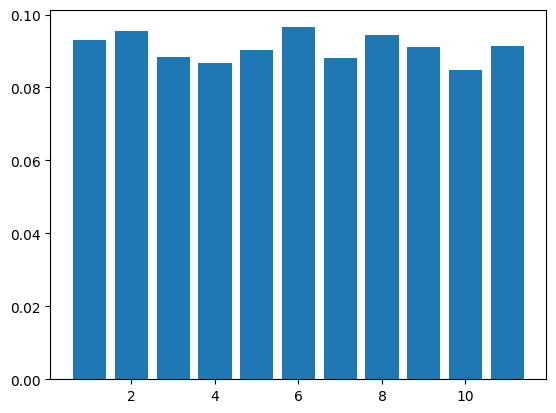

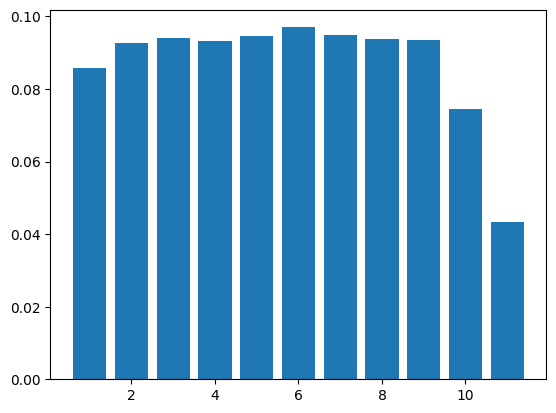

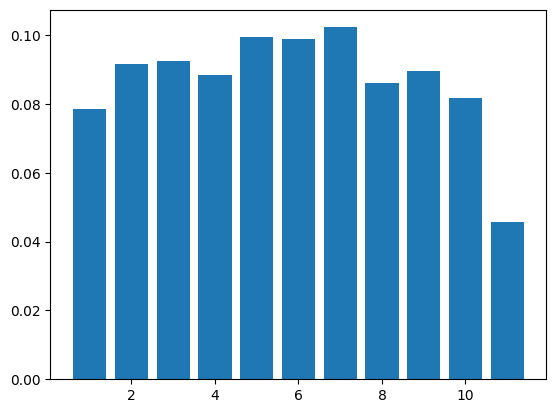

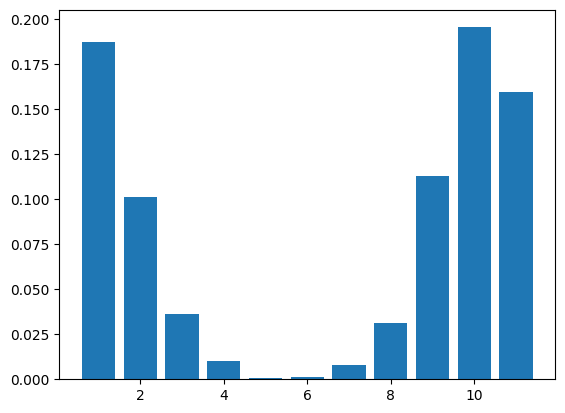

In [ ]:
# start by generating the four neurons with at least 2000 activity values
N = 8000
testNeurons = fourneurons(N)
# generate histogram for each of 4 neurons at the 11 activation levels
N1Hist = np.histogram(testNeurons[0], bins=11, range=[1,12])
N2Hist = np.histogram(testNeurons[1], bins=11, range=[1,12])
N3Hist = np.histogram(testNeurons[2], bins=11, range=[1,12])
N4Hist = np.histogram(testNeurons[3], bins=11, range=[1,12])
# calculate the marginal probability from the histogram counts
N1Prob = N1Hist[0]/N
N2Prob = N2Hist[0]/N
N3Prob = N3Hist[0]/N
N4Prob = N4Hist[0]/N
# plot the histograms of the marginal probabilities
plt.figure()
plt.bar(N1Hist[1][:-1],N1Prob)
plt.show()
plt.figure()
plt.bar(N2Hist[1][:-1],N2Prob)
plt.show()
plt.bar(N3Hist[1][:-1],N3Prob)
plt.figure()
plt.bar(N4Hist[1][:-1],N4Prob)
plt.show()

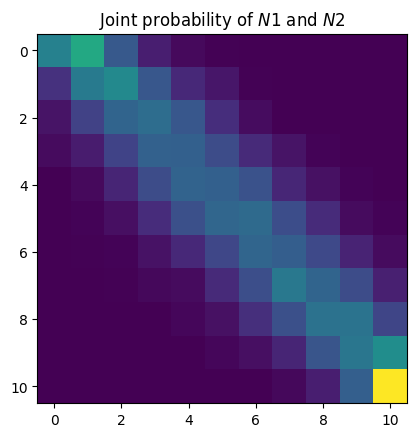

1.0


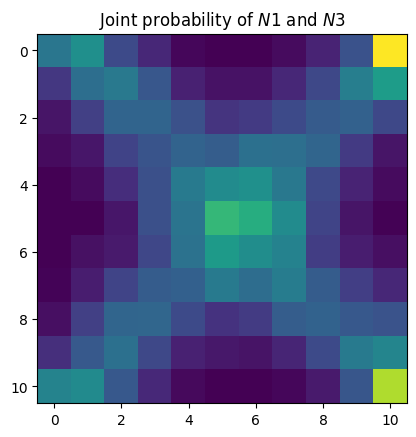

0.9999999999999999


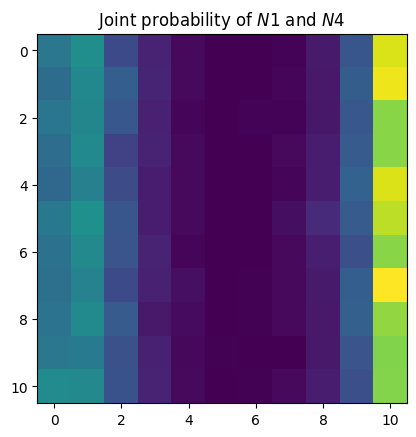

0.9999999999999999


In [ ]:
# calculate the joint probability with histogram2d
p_r1_r2, x, y = np.histogram2d(testNeurons[0], testNeurons[1], bins=11)#, range=[[1,11],[1,11]])
p_r1_r2 /= N
plt.imshow(p_r1_r2)
plt.title('Joint probability of $N1$ and $N2$')
plt.show()
# print the sum of the join probability matrix to confirm that it adds to 1
print(np.sum(p_r1_r2))

p_r1_r3, x, y = np.histogram2d(testNeurons[0], testNeurons[2], bins=11)#, range=[[1,12],[1,12]])
p_r1_r3 /= N
plt.imshow(p_r1_r3)
plt.title('Joint probability of $N1$ and $N3$')
plt.show()
print(np.sum(p_r1_r3))

p_r1_r4, x, y = np.histogram2d(testNeurons[0], testNeurons[3], bins=11)#, range=[[1,12],[1,12]])
p_r1_r4 /= N
plt.imshow(p_r1_r4)
plt.title('Joint probability of $N1$ and $N4$')
plt.show()
print(np.sum(p_r1_r4))

[[ 1.          0.89297465 -0.01223717  0.01308147]
 [ 0.89297465  1.         -0.00950903  0.01654109]
 [-0.01223717 -0.00950903  1.          0.00401707]
 [ 0.01308147  0.01654109  0.00401707  1.        ]]


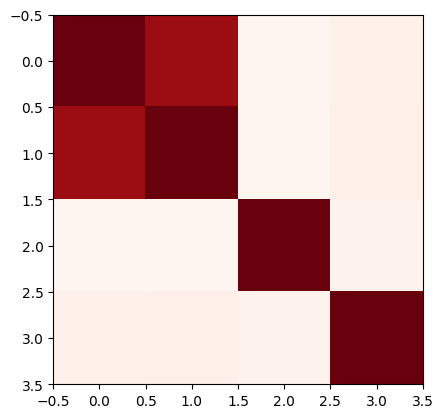

In [ ]:
# calculate correlation coefficient for each neuron pair
rho_r1_r2 = np.corrcoef(testNeurons)
print(rho_r1_r2)
plt.imshow(rho_r1_r2, cmap='Reds')

## Mutual information

Compute marginal entropies $H(r_1)$, $H(r_2)$, $H(r_3)$, and $H(r_4)$, joint entropies $H(r_1, r_2)$,  $H(r_1, r_3)$, and $H(r_1, r_4)$ for each neuron pair.  It is convenient to program a function for this purpose.
$$
H(r_i)=-\sum_{r_i=1}^{11} P(r_i) \, \log_2 P(r_i), \qquad\qquad H(r_i,r_j)=-\sum_{r_i=1}^{11} \sum_{r_j=1}^{11} P(r_i,r_j) \, \log_2 P(r_i,r_j)
$$

Finally, compute the mutual information for each neuron pair:

$$
I_m(r_1,r_2) = H(r_1)+H(r_2)-H(r_1,r_2)
$$
$$
I_m(r_1,r_3) = H(r_1)+H(r_3)-H(r_1,r_3)
$$
$$
I_m(r_1,r_4) = H(r_1)+H(r_4)-H(r_1,r_4)
$$

In [ ]:
# mutual information
# compute the marginal entropy
def marginalEntropy(P_ri):
  H_ri = 0
  for i in range(len(P_ri)):
    H_ri += P_ri[i] * np.log2(P_ri[i])
  return -H_ri

H_r1 = marginalEntropy(N1Prob)
print(H_r1)
H_r2 = marginalEntropy(N2Prob)
print(H_r2)
H_r3 = marginalEntropy(N3Prob)
print(H_r3)
H_r4 = marginalEntropy(N4Prob)
print(H_r4)
def jointEntropy(P_ri_rj):
  H_ri_rj = 0
  smallNumber = 0.01
  for i in range(P_ri_rj.shape[0]):
    for j in range(P_ri_rj.shape[1]):
      if P_ri_rj[i,j] != 0:
        H_ri_rj += P_ri_rj[i,j] * np.log2(P_ri_rj[i,j])
      else:
        H_ri_rj += smallNumber
  return -H_ri_rj

H_r1_r2 = jointEntropy(p_r1_r2)
print(H_r1_r2)
Im_r1_r2 = H_r1 + H_r2 - H_r1_r2
print(Im_r1_r2)
H_r1_r3 = jointEntropy(p_r1_r3)
print(H_r1_r3)
Im_r1_r3 = H_r1 + H_r3 - H_r1_r3
print(Im_r1_r3)
H_r1_r4 = jointEntropy(p_r1_r4)
print(H_r1_r4)
Im_r1_r4 = H_r1 + H_r4 - H_r1_r4
print(Im_r1_r4)

3.4583431169893046
3.3476506711351286
3.3439178951735995
2.500523134025638
5.532019697846888
1.2739740902775454
6.416173527850082
0.3860874843128217
5.915582264422874
0.043283986592068224
